# Matrix Factorization — MovieLens Latest Small

Biased Matrix Factorization trained with SGD.

**Model:**
```
r̂(u,i) = μ + b_u + b_i + P[u] · Q[i]
```

- `μ`    — global mean (scalar, fixed)
- `b_u`  — user bias (learned)
- `b_i`  — item bias (learned)
- `P[u]` — user latent vector, K-dimensional (learned)
- `Q[i]` — item latent vector, K-dimensional (learned)

**Loss (regularised MSE):**
```
L = Σ (r_{ui} - r̂_{ui})²  +  λ(||P[u]||² + ||Q[i]||² + b_u² + b_i²)
```

**Targets to beat (from baselines):**

| Metric | Best baseline (User+Item Bias) |
|---|---|
| RMSE | 0.8573 |
| MAE  | 0.6564 |


## 1. Imports & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

train  = pd.read_csv("train.csv")
test   = pd.read_csv("test.csv")
movies = pd.read_csv("movies_clean.csv")

N_USERS  = train.user_idx.nunique()
N_MOVIES = train.movie_idx.nunique()
RATING_MIN, RATING_MAX = 0.5, 5.0

# baseline targets to beat
BASELINE_RMSE = 0.8573
BASELINE_MAE  = 0.6564

print(f"Users  : {N_USERS}")
print(f"Movies : {N_MOVIES}")
print(f"Train  : {len(train):,}  |  Test: {len(test):,}")
print(f"Global mean μ = {train.rating.mean():.4f}")


Users  : 610
Movies : 2269
Train  : 65,130  |  Test: 15,986
Global mean μ = 3.5739


## 2. Evaluation Metrics

In [3]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def precision_recall_at_k(model, test_df, train_df, k=10, threshold=4.0):
    """
    For each user:
      1. Generate top-K recommendations (exclude movies seen in train)
      2. Relevant = test movies with rating >= threshold
      3. Precision@K = hits / K
      4. Recall@K    = hits / total relevant
    """
    train_seen = train_df.groupby("user_idx")["movie_idx"].apply(set).to_dict()
    test_relevant = (
        test_df[test_df["rating"] >= threshold]
        .groupby("user_idx")["movie_idx"]
        .apply(set)
        .to_dict()
    )

    precisions, recalls = [], []

    for user_idx, relevant in test_relevant.items():
        seen     = train_seen.get(user_idx, set())
        recs     = model.recommend(user_idx, n=k, seen_items=seen)
        rec_set  = {movie_idx for movie_idx, _ in recs}
        hits     = len(rec_set & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant) if relevant else 0.0)

    p, r = np.mean(precisions), np.mean(recalls)
    f1   = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1


## 3. Matrix Factorization Model

SGD update rules derived from the loss gradient (see derivation in `recommender.py`):

```
b_u ← b_u + lr · (err - λ · b_u)
b_i ← b_i + lr · (err - λ · b_i)
P[u] ← P[u] + lr · (err · Q[i] - λ · P[u])   # uses OLD Q[i]
Q[i] ← Q[i] + lr · (err · P[u] - λ · Q[i])   # uses OLD P[u]
```

We cache `pu = P[u].copy()` and `qi = Q[i].copy()` before updates to avoid aliasing —  
both updates must use the vectors from *before* this step.


In [4]:
class MatrixFactorization:

    def __init__(self, n_users, n_movies, n_factors=20, lr=0.005, reg=0.02, seed=42):
        self.n_factors = n_factors
        self.lr        = lr
        self.reg       = reg

        rng   = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(n_factors)

        self.P  = rng.normal(0, scale, (n_users,  n_factors))  # user embeddings
        self.Q  = rng.normal(0, scale, (n_movies, n_factors))  # movie embeddings
        self.bu = np.zeros(n_users)                            # user biases
        self.bi = np.zeros(n_movies)                           # movie biases
        self.mu = 0.0                                          # global mean

    def predict_one(self, u, i):
        return self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]

    def predict_batch(self, user_idxs, movie_idxs):
        """Vectorised prediction for arrays of (user, movie) pairs."""
        dots = np.einsum("nd,nd->n", self.P[user_idxs], self.Q[movie_idxs])
        return self.mu + self.bu[user_idxs] + self.bi[movie_idxs] + dots

    def fit(self, train_df, val_df=None, n_epochs=20, verbose=True):
        self.mu = train_df["rating"].mean()

        users = train_df["user_idx"].values
        items = train_df["movie_idx"].values
        rvals = train_df["rating"].values.astype(float)
        n     = len(rvals)

        train_rmse_hist, val_rmse_hist = [], []
        rng = np.random.default_rng(0)

        for epoch in range(1, n_epochs + 1):
            t0   = time.time()
            perm = rng.permutation(n)
            u_s, i_s, r_s = users[perm], items[perm], rvals[perm]

            sq_err = 0.0
            for k in range(n):
                u, i, r = u_s[k], i_s[k], r_s[k]
                err      = r - self.predict_one(u, i)
                sq_err  += err ** 2

                # cache before update — prevents aliasing
                pu = self.P[u].copy()
                qi = self.Q[i].copy()

                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                self.P[u]  += self.lr * (err * qi - self.reg * pu)
                self.Q[i]  += self.lr * (err * pu - self.reg * qi)

            train_rmse = np.sqrt(sq_err / n)
            train_rmse_hist.append(train_rmse)

            val_rmse = None
            if val_df is not None:
                val_preds = np.clip(
                    self.predict_batch(val_df["user_idx"].values,
                                       val_df["movie_idx"].values),
                    RATING_MIN, RATING_MAX
                )
                val_rmse = rmse(val_df["rating"].values, val_preds)
                val_rmse_hist.append(val_rmse)

            if verbose:
                val_str = f"  val RMSE={val_rmse:.4f}" if val_rmse else ""
                print(f"Epoch {epoch:>2}/{n_epochs}  "
                      f"train RMSE={train_rmse:.4f}{val_str}  "
                      f"({time.time()-t0:.1f}s)")

        return train_rmse_hist, val_rmse_hist

    def recommend(self, user_idx, n=10, seen_items=None):
        """
        Score all unseen movies for a user, return top-N (movie_idx, score) pairs.
        Vectorised — one dot product across all movies simultaneously.
        """
        all_movies = np.arange(self.Q.shape[0])

        if seen_items is not None:
            mask      = ~np.isin(all_movies, list(seen_items))
            candidates = all_movies[mask]
        else:
            candidates = all_movies

        scores = (self.mu
                  + self.bu[user_idx]
                  + self.bi[candidates]
                  + self.P[user_idx] @ self.Q[candidates].T)

        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return list(zip(candidates[top_idx], scores[top_idx]))


## 4. Train

Hyperparameters:
- `n_factors=20` — dimensionality of latent space
- `lr=0.005` — learning rate
- `reg=0.02` — L2 regularisation strength
- `n_epochs=20`


In [15]:
model = MatrixFactorization(
    n_users=N_USERS, n_movies=N_MOVIES,
    n_factors=15, lr=0.005, reg=0.1
)

train_hist, val_hist = model.fit(train, val_df=test, n_epochs=17, verbose=True)


Epoch  1/17  train RMSE=0.9803  val RMSE=0.9401  (0.5s)
Epoch  2/17  train RMSE=0.9111  val RMSE=0.9095  (0.5s)
Epoch  3/17  train RMSE=0.8810  val RMSE=0.8935  (0.5s)
Epoch  4/17  train RMSE=0.8623  val RMSE=0.8834  (0.5s)
Epoch  5/17  train RMSE=0.8495  val RMSE=0.8762  (0.5s)
Epoch  6/17  train RMSE=0.8396  val RMSE=0.8712  (0.5s)
Epoch  7/17  train RMSE=0.8320  val RMSE=0.8670  (0.5s)
Epoch  8/17  train RMSE=0.8259  val RMSE=0.8640  (0.5s)
Epoch  9/17  train RMSE=0.8207  val RMSE=0.8611  (0.5s)
Epoch 10/17  train RMSE=0.8162  val RMSE=0.8588  (0.5s)
Epoch 11/17  train RMSE=0.8125  val RMSE=0.8575  (0.5s)
Epoch 12/17  train RMSE=0.8091  val RMSE=0.8559  (0.5s)
Epoch 13/17  train RMSE=0.8061  val RMSE=0.8547  (0.5s)
Epoch 14/17  train RMSE=0.8035  val RMSE=0.8537  (0.5s)
Epoch 15/17  train RMSE=0.8009  val RMSE=0.8525  (0.5s)
Epoch 16/17  train RMSE=0.7987  val RMSE=0.8518  (0.5s)
Epoch 17/17  train RMSE=0.7965  val RMSE=0.8513  (0.5s)


## 5. Evaluate

In [16]:
test_preds = np.clip(
    model.predict_batch(test["user_idx"].values, test["movie_idx"].values),
    RATING_MIN, RATING_MAX
)

test_rmse = rmse(test["rating"].values, test_preds)
test_mae  = mae(test["rating"].values, test_preds)

K = 10
p_at_k, r_at_k, f1_at_k = precision_recall_at_k(model, test, train, k=K, threshold=4.0)

print("=" * 55)
print(f"  {'Metric':<25} {'Baseline':>10}  {'MF':>10}  {'Δ':>8}")
print("=" * 55)
print(f"  {'RMSE':<25} {BASELINE_RMSE:>10.4f}  {test_rmse:>10.4f}  "
      f"{BASELINE_RMSE - test_rmse:>+8.4f}")
print(f"  {'MAE':<25} {BASELINE_MAE:>10.4f}  {test_mae:>10.4f}  "
      f"{BASELINE_MAE - test_mae:>+8.4f}")
print(f"  {'Precision@10':<25} {'—':>10}  {p_at_k:>10.4f}")
print(f"  {'Recall@10':<25} {'—':>10}  {r_at_k:>10.4f}")
print(f"  {'F1@10':<25} {'—':>10}  {f1_at_k:>10.4f}")
print("=" * 55)

improvement = (BASELINE_RMSE - test_rmse) / BASELINE_RMSE * 100
print(f"\n  RMSE improvement over best baseline: {improvement:.2f}%")


  Metric                      Baseline          MF         Δ
  RMSE                          0.8573      0.8513   +0.0060
  MAE                           0.6564      0.6538   +0.0026
  Precision@10                       —      0.0365
  Recall@10                          —      0.0208
  F1@10                              —      0.0265

  RMSE improvement over best baseline: 0.70%


## 6. Visualisation

C:\Users\Hites\AppData\Local\Temp\ipykernel_25872\3653555241.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


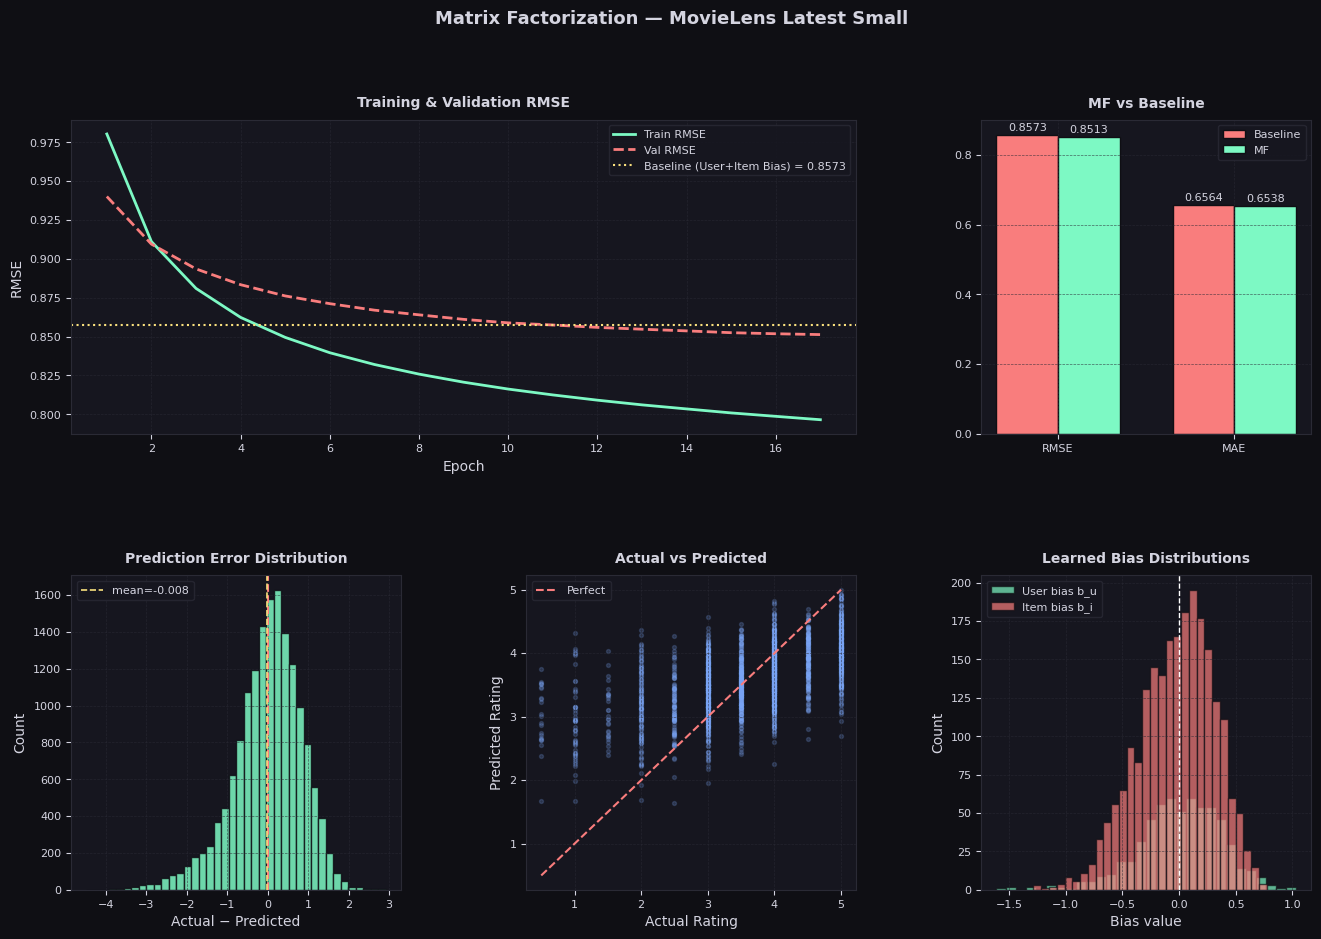

In [17]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

actual = test["rating"].values

# (a) Loss curves
ax = fig.add_subplot(gs[0, :2])
epochs = range(1, len(train_hist) + 1)
ax.plot(epochs, train_hist, color=ACCENT,  lw=2, label="Train RMSE")
ax.plot(epochs, val_hist,   color=ACCENT2, lw=2, label="Val RMSE", linestyle="--")
ax.axhline(BASELINE_RMSE, color=ACCENT4, lw=1.5, linestyle=":",
           label=f"Baseline (User+Item Bias) = {BASELINE_RMSE}")
ax.set_xlabel("Epoch"); ax.set_ylabel("RMSE")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Training & Validation RMSE")

# (b) Metrics bar chart
ax = fig.add_subplot(gs[0, 2])
labels = ["RMSE", "MAE"]
baseline_vals = [BASELINE_RMSE, BASELINE_MAE]
mf_vals       = [test_rmse, test_mae]
x = np.arange(len(labels))
w = 0.35
b1 = ax.bar(x - w/2, baseline_vals, w, color=ACCENT2, label="Baseline", edgecolor=BG)
b2 = ax.bar(x + w/2, mf_vals,       w, color=ACCENT,  label="MF",       edgecolor=BG)
for b, v in list(zip(b1, baseline_vals)) + list(zip(b2, mf_vals)):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005,
            f"{v:.4f}", ha="center", va="bottom", color=TEXT_C, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "MF vs Baseline")

# (c) Prediction error distribution
ax = fig.add_subplot(gs[1, 0])
errors = actual - test_preds
ax.hist(errors, bins=40, color=ACCENT, edgecolor=BG, alpha=0.85)
ax.axvline(0, color=ACCENT2, lw=1.5, linestyle="--")
ax.axvline(errors.mean(), color=ACCENT4, lw=1.2, linestyle="--",
           label=f"mean={errors.mean():.3f}")
ax.set_xlabel("Actual − Predicted"); ax.set_ylabel("Count")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Prediction Error Distribution")

# (d) Actual vs predicted scatter
ax = fig.add_subplot(gs[1, 1])
sample = np.random.default_rng(0).choice(len(test_preds), min(2000, len(test_preds)), replace=False)
ax.scatter(actual[sample], test_preds[sample], alpha=0.2, s=8, color=ACCENT3)
ax.plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX],
        color=ACCENT2, lw=1.5, linestyle="--", label="Perfect")
ax.set_xlabel("Actual Rating"); ax.set_ylabel("Predicted Rating")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Actual vs Predicted")

# (e) Learned user bias distribution
ax = fig.add_subplot(gs[1, 2])
ax.hist(model.bu, bins=30, color=ACCENT,  edgecolor=BG, alpha=0.7, label="User bias b_u")
ax.hist(model.bi, bins=30, color=ACCENT2, edgecolor=BG, alpha=0.7, label="Item bias b_i")
ax.axvline(0, color="white", lw=1, linestyle="--")
ax.set_xlabel("Bias value"); ax.set_ylabel("Count")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Learned Bias Distributions")

fig.suptitle("Matrix Factorization — MovieLens Latest Small",
             color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


## 7. Sample Recommendations

For a few users, show:
- Their top-rated movies in train (what the model learned from)
- The model's top-10 recommendations (unseen movies)


In [18]:
movie_lookup = movies.set_index("movie_idx")[["title_clean", "year", "genres"]]

def show_recommendations(user_idx, n=10):
    # what this user liked in training
    user_train = train[train["user_idx"] == user_idx].copy()
    user_train = user_train.merge(
        movies[["movie_idx","title_clean","genres"]], on="movie_idx"
    ).sort_values("rating", ascending=False)

    print(f"User {user_idx} — top rated in train:")
    for _, row in user_train.head(5).iterrows():
        print(f"  {row['rating']:.1f}  {row['title_clean']}  [{row['genres']}]")
    print()

    # recommendations
    seen  = set(train[train["user_idx"] == user_idx]["movie_idx"].values)
    recs  = model.recommend(user_idx, n=n, seen_items=seen)

    print(f"  Top-{n} recommendations:")
    print(f"  {'Rank':<5} {'Title':<45} {'Genres':<35} {'Score':>5}")
    print("  " + "─" * 92)
    for rank, (midx, score) in enumerate(recs, 1):
        row = movie_lookup.loc[midx]
        title  = str(row["title_clean"])[:43]
        genres = str(row["genres"])[:33]
        print(f"  {rank:<5} {title:<45} {genres:<35} {score:>5.3f}")
    print()

# show 3 different users
for uid in [0, 42, 100]:
    print("=" * 95)
    show_recommendations(uid, n=10)


User 0 — top rated in train:
  5.0  Winnie the Pooh and the Blustery Day  [Animation|Children|Musical]
  5.0  Seven (a.k.a. Se7en)  [Mystery|Thriller]
  5.0  Back to the Future  [Adventure|Comedy|Sci-Fi]
  5.0  Rob Roy  [Action|Drama|Romance|War]
  5.0  Robin Hood  [Adventure|Animation|Children|Comedy|Musical]

  Top-10 recommendations:
  Rank  Title                                         Genres                              Score
  ────────────────────────────────────────────────────────────────────────────────────────────
  1     Dr. Strangelove or: How I Learned to Stop W   Comedy|War                          5.071
  2     Lawrence of Arabia                            Adventure|Drama|War                 5.035
  3     Shawshank Redemption, The                     Crime|Drama                         5.020
  4     Great Escape, The                             Action|Adventure|Drama|War          4.961
  5     Philadelphia Story, The                       Comedy|Drama|Romance            

## 8. Latent Space Peek

The dot product `P[u] · Q[i]` is what makes MF personalised.  
Users with similar taste should have similar `P[u]` vectors.  
We can verify this by finding the most similar users to a given user via cosine similarity.


In [19]:
def cosine_similarity_matrix(M):
    """Row-wise cosine similarity for matrix M."""
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-9, norms)
    return (M / norms) @ (M / norms).T

user_sim = cosine_similarity_matrix(model.P)

def similar_users(user_idx, n=5):
    sims  = user_sim[user_idx]
    sims[user_idx] = -1   # exclude self
    top   = np.argsort(sims)[-n:][::-1]
    print(f"Users most similar to User {user_idx}:")
    for u in top:
        print(f"  User {u:<5}  cosine sim={sims[u]:.4f}  "
              f"(rated {len(train[train.user_idx==u])} movies)")

similar_users(0)
print()
similar_users(42)

print()
print(f"P matrix shape : {model.P.shape}  (users  × factors)")
print(f"Q matrix shape : {model.Q.shape}  (movies × factors)")
print(f"Latent factors : {model.n_factors}")


Users most similar to User 0:
  User 571    cosine sim=0.7472  (rated 112 movies)
  User 136    cosine sim=0.7457  (rated 100 movies)
  User 233    cosine sim=0.6912  (rated 136 movies)
  User 113    cosine sim=0.6850  (rated 23 movies)
  User 114    cosine sim=0.6740  (rated 88 movies)

Users most similar to User 42:
  User 142    cosine sim=0.6888  (rated 42 movies)
  User 151    cosine sim=0.6658  (rated 48 movies)
  User 325    cosine sim=0.6652  (rated 96 movies)
  User 458    cosine sim=0.6137  (rated 21 movies)
  User 576    cosine sim=0.6041  (rated 119 movies)

P matrix shape : (610, 15)  (users  × factors)
Q matrix shape : (2269, 15)  (movies × factors)
Latent factors : 15
